<a href="https://colab.research.google.com/github/Jackline-Jebet/Streaming-Analytics-NLP-Pipeline-ML-/blob/main/NLP_Analysis_Word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark -q
from pyspark.sql import SparkSession
from pyspark.ml.feature import Word2Vec, Tokenizer, StopWordsRemover
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import string

In [ ]:
# Initialization of Spark Session
spark = SparkSession.builder.appName("Word2Vec_14M_Corpus").getOrCreate()

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Loading the text data
data = spark.read.text('drive/My Drive/Colab Notebooks/corpus.txt')

In [ ]:
data = data.selectExpr("value as sentence")

In [ ]:
# Tokenize the text into words
tokenizer = Tokenizer(inputCol="sentence", outputCol="words")
tokenized = tokenizer.transform(data)

print(tokenized.show())

+--------------------+--------------------+
|            sentence|               words|
+--------------------+--------------------+
|The Fulton County...|[the, fulton, cou...|
|The jury further ...|[the, jury, furth...|
|                    |                  []|
|The September-Oct...|[the, september-o...|
|"Only a relative ...|["only, a, relati...|
|The jury said it ...|[the, jury, said,...|
|It recommended th...|[it, recommended,...|
|The grand jury co...|[the, grand, jury...|
|                    |                  []|
|   #MERGER PROPOSED#|[#merger, proposed#]|
|                    |                  []|
|However, the jury...|[however,, the, j...|
|The City Purchasi...|[the, city, purch...|
|Implementation of...|[implementation, ...|
|                    |                  []|
|It urged that the...|[it, urged, that,...|
|The grand jury to...|[the, grand, jury...|
|"This is one of t...|["this, is, one, ...|
|The jurors said t...|[the, jurors, sai...|
|Nevertheless, "we...|[neverthel

In [ ]:
# Removal of stop words
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
filtered = remover.transform(tokenized)

filtered.show()
filtered.count()

+--------------------+--------------------+--------------------+
|            sentence|               words|      filtered_words|
+--------------------+--------------------+--------------------+
|The Fulton County...|[the, fulton, cou...|[fulton, county, ...|
|The jury further ...|[the, jury, furth...|[jury, said, term...|
|                    |                  []|                  []|
|The September-Oct...|[the, september-o...|[september-octobe...|
|"Only a relative ...|["only, a, relati...|["only, relative,...|
|The jury said it ...|[the, jury, said,...|[jury, said, find...|
|It recommended th...|[it, recommended,...|[recommended, ful...|
|The grand jury co...|[the, grand, jury...|[grand, jury, com...|
|                    |                  []|                  []|
|   #MERGER PROPOSED#|[#merger, proposed#]|[#merger, proposed#]|
|                    |                  []|                  []|
|However, the jury...|[however,, the, j...|[however,, jury, ...|
|The City Purchasi...|[th

187043

In [ ]:
# Training Word2Vec model - filtererd
word2vec = Word2Vec(vectorSize=100, minCount=5, inputCol="filtered_words", outputCol="embeddings", numPartitions=10)
model = word2vec.fit(filtered)
print(model)

Word2VecModel: uid=Word2Vec_7b2ea6a38cd0, numWords=88536, vectorSize=100


In [ ]:
# Finding the nearest neighbors
words_to_check = ["data", "machine", "book", "learning", "technology"]  # Domain-relevant words
for word in words_to_check:
    synonyms = model.findSynonyms(word, 5)
    print(f"Nearest neighbors for {word}:")
    synonyms.show()

Nearest neighbors for data:
+--------+------------------+
|    word|        similarity|
+--------+------------------+
|   data,|0.7403317093849182|
| figures|0.7225280404090881|
|   data.|0.6968784332275391|
|  survey|0.6855697631835938|
|non-farm|0.6611144542694092|
+--------+------------------+

Nearest neighbors for machine:
+---------+------------------+
|     word|        similarity|
+---------+------------------+
| sensors,|0.7937257289886475|
|machines,| 0.779524564743042|
|  optical|0.7717289328575134|
| molecule|0.7669968008995056|
|   robots|0.7639395594596863|
+---------+------------------+

Nearest neighbors for book:
+---------+------------------+
|     word|        similarity|
+---------+------------------+
|      sks| 0.588696300983429|
|    (p/b)|0.5858091115951538|
|     nav,|0.5719316601753235|
|multiples|0.5717687010765076|
|      tag|0.5712257027626038|
+---------+------------------+

Nearest neighbors for learning:
+---------------+------------------+
|           w

In [ ]:
# Visualize the embeddings with enhancements
vectors = model.getVectors().select("word", "vector").collect()
words = [row["word"] for row in vectors]
vecs = [row["vector"].toArray() for row in vectors]
print(words)


['specifically,', "pelosi's", 'unlikely.', 'onam', 'professed', 'maintained,', 'pathogens', 'shibor', '~mm', 'ihss', 'herself.', '($3.2', 'quotient', 'incident', 'meteorologist', '^june', 'lauryl', 'misfire', 'wu;', 'petulant,', 'buns', 'eaten,', 'serious', '(msft.o),', 'ninth.', 'brink', '773-301-6437', "'low", 'showdowns', 'india?', 'dayton,', '9/11', '87%', 'primoris,', 'acronym', 'boutiques', 'youthful', 'sinister', 'comply', 'ebb', 'breaks', 'bradesco', 'marr', 'temperature,', 'forgotten', '$446', 'burqa', 'precious', 'mario', 'stop,', 'brownfield', '12:22', 'better."', '702,', 'boxers', '2014-15,', 'expenditures;', 'compliment', 'suite,', '37th', 'inflammatory', '$0.12', 'w/o', 'sectors', 'ascension', 'double-barrelled', '64,', 'teresa', 'hourly', 'gandhi.', 'got,', 'thunderous', 'thinner,', '(ge.n)', 'embedded', 'rationalising', 'respecting', 'quicker,', 'allotments', 'lithuanian', 'militarily,', 'merkel,', '5-6%', 'derided', 'mcdermidthe', 'sputtering', 'pkk', '(005930.ks)', '(

In [ ]:
# Reduce the dimensions with PCA
# pca = PCA(n_components=2)
# reduced_vecs = pca.fit_transform(vecs)

In [ ]:
# Subset for visualization
subset_size = 1000  # Limit to 1000 words
subset_indices = np.random.choice(len(words), subset_size, replace=False)
subset_words = [words[i] for i in subset_indices]
subset_vecs = [vecs[i] for i in subset_indices]
print(subset_words)

['plan', 'murder', 'cut-off', 'gdp,"', "wife's", 'imposing', '8.14', 'madison.', '‘china', 'kevin', 'suburb.', 'dupont,', 'nordangliaeducation.com', 'malaria,', 'securus', 'hijacking', 'alloy,', 'die-hard', 'walmart.', 'hipwell', 'del.wilber@wsj.com', '11.1%', 'byproducts', 'defrauding', 'degrom,', '38.8', 'laden', 'suction', 'may’s', 'unpalatable', 'concert,', 'fighting,', 'bandaged', '$45.83', 'want,', 'scratching', 'warned:', 'apolitical', 'sizzle', 'convenient', 'customized', 'iq.', 'differences.', 'fourth', 'patriotism.', 'highs,', 'fuchs', 'sliced', 'tribunals', 'buddies', 'moscow-backed', 'hain', "period's", 'old-world', 'smartphones', '(kr.n),', 'problem-solving', 'dating,', 'expedited', 'dod', 'milwaukee.', 'francis.', '2035', 'repeated,', 'ridicule', 'slovenian', 'animus', 'crowd-sourced', 'transcontinental', 'trader.', 'digestive', 'silent', 'demolition', 'newsroom', 'sherwood,', 'opponents.', 'ranger', 'primary-care', 'marston', 'info@bgandg.com', 'low-skilled', '24th', 'tr

In [ ]:
# Import the TSNE class from sklearn.manifold
from sklearn.manifold import TSNE

# Reduce dimensions with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
reduced_vecs = tsne.fit_transform(np.array(subset_vecs))

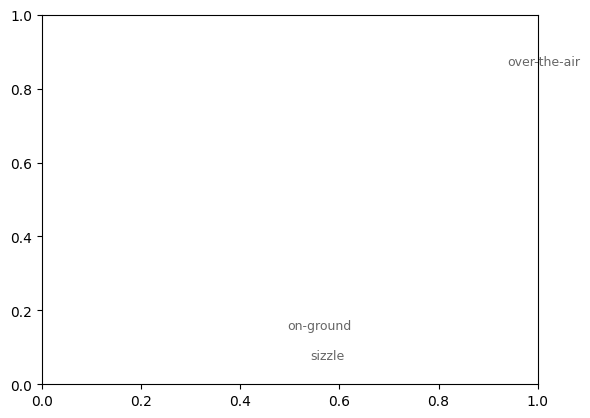

In [ ]:
# Add more word annotations
for i, word in enumerate(subset_words):
    plt.annotate(word, (reduced_vecs[i, 0], reduced_vecs[i, 1]),
                 fontsize=9, alpha=0.6)


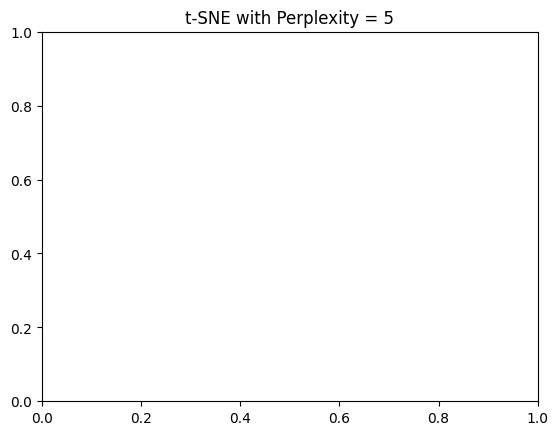

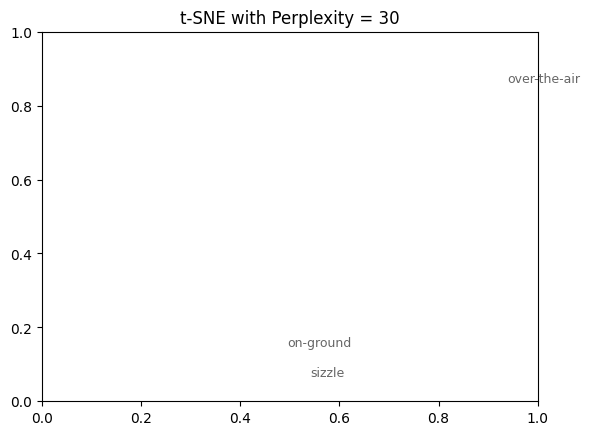

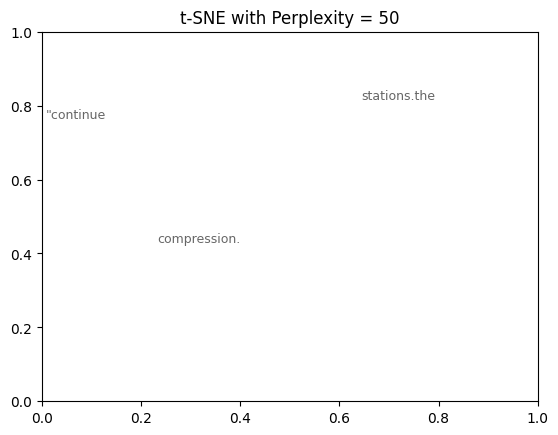

In [ ]:
# Use different t-SNE parameters to compare clustering behavior
for perp in [5, 30, 50]:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    reduced = tsne.fit_transform(np.array(subset_vecs))
    for i, word in enumerate(subset_words):
        plt.annotate(word, (reduced[i, 0], reduced[i, 1]),
                     fontsize=9, alpha=0.6)
        plt.title(f"t-SNE with Perplexity = {perp}")
    plt.show()


In [ ]:
# Interactive plotting with plotly
import plotly.express as px
import pandas as pd

# Create a DataFrame
df = pd.DataFrame({
    'x': reduced_vecs[:, 0],
    'y': reduced_vecs[:, 1],
    'word': subset_words
})

# scatter plot
fig = px.scatter(df, x='x', y='y', text='word', title='t-SNE Word2Vec Visualization')
fig.update_traces(textposition='top center')
fig.update_layout(height=600, width=800)
fig.show()

In [ ]:
# Auto-categorization via clustering
from sklearn.cluster import KMeans

# Cluster the 2D points
kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(reduced_vecs)

# Plot with cluster coloring
fig = px.scatter(df, x='x', y='y', text='word', color='cluster',
                 title='t-SNE Word2Vec with KMeans Clustering')
fig.update_traces(textposition='top center')
fig.update_layout(height=600, width=800)
fig.show()


In [ ]:
# Alternatively

import string

# Sample categories mapping
categories_clean = {
    'gdp': 'economics',
    'jury': 'law',
    'merger': 'business',
    'recommended': 'suggestion',
    'city': 'location',
    'economics': 'economics',
    'defendant': 'law',
    'law': 'law',
    'business': 'business',
    'suggestion': 'suggestion',
    'location': 'location'
}

In [ ]:
def clean_word(word):
    return word.strip().lower().translate(str.maketrans('', '', string.punctuation))

# Clean the tokenized words from the dataset
subset_words_clean = [
    # Example of tokenized words for some of the rows
    ['the', 'fulton', 'county', 'jury', 'said', 'gdp'],
    ['the', 'jury', 'further', 'recommended'],
    ['merger', 'proposed', 'economics'],
    ['only', 'relative', 'suggested']
]

In [ ]:
reduced_vecs = np.random.rand(100, 2)

In [ ]:
# Define colors for categories
colors = {'economics': 'blue', 'law': 'red', 'business': 'green', 'suggestion': 'orange', 'location': 'purple'}


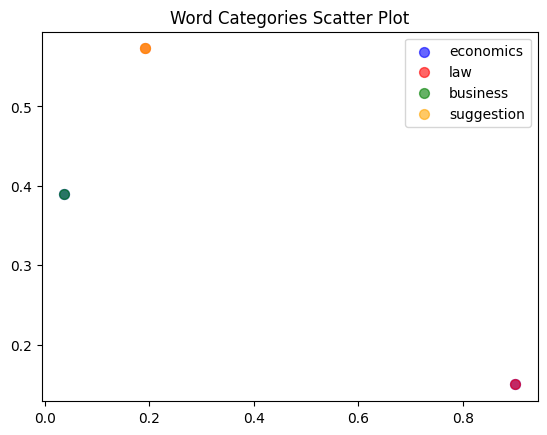

In [ ]:
for category, color in colors.items():
    indices = []

    # Find words that match the category
    for i, words in enumerate(subset_words_clean):
        for word in words:
            clean_word_ = clean_word(word)
            if clean_word_ in categories_clean and categories_clean[clean_word_] == category:
                indices.append(i)
                break

    # Only plot if indices are non-empty
    if indices:
        plt.scatter(
            reduced_vecs[indices, 0], reduced_vecs[indices, 1],
            c=color, label=category, alpha=0.6, s=50
        )

# Customize plot
plt.title('Word Categories Scatter Plot')
plt.legend()
plt.show()

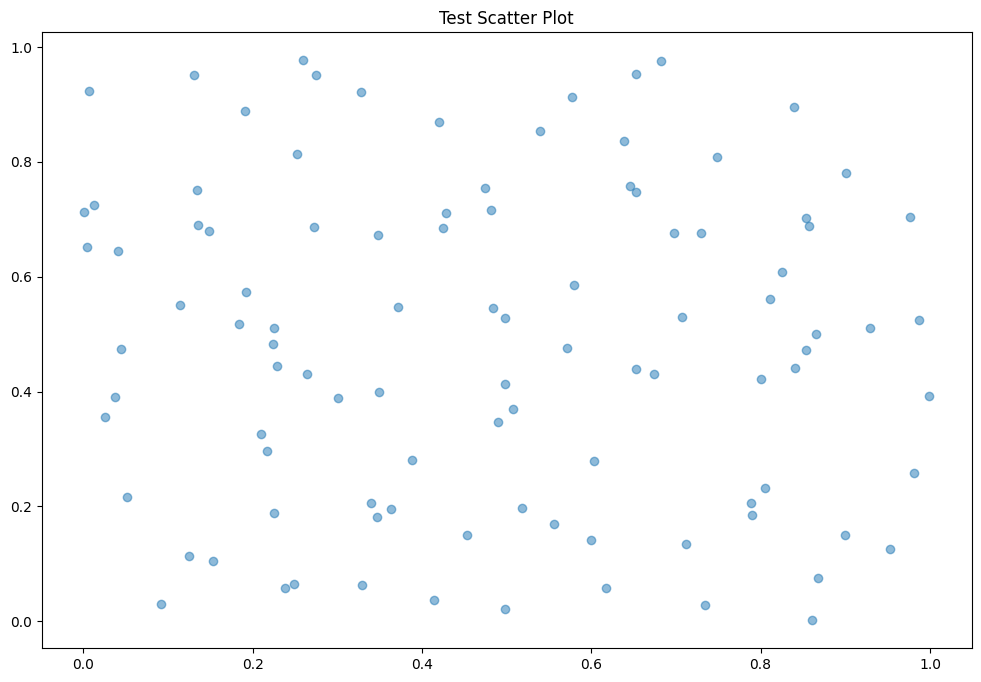

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(reduced_vecs[:, 0], reduced_vecs[:, 1], alpha=0.5)
plt.title("Test Scatter Plot"),
plt.show()

In [ ]:
# Annotate specific words of interest
words_to_annotate = ["data", "machine", "book", "learning", "technology", "science", "author"]  # Adjust based on vocabulary
for word in words_to_annotate:
    if word in words:
        idx = words.index(word)
        plt.annotate(word, (reduced_vecs[idx, 0], reduced_vecs[idx, 1]), fontsize=10, color='black', ha='center')


In [ ]:
# Annotate specific words of interest with a background
words_to_annotate = ["data", "machine", "book", "learning", "technology", "science", "author"]
for word in words_to_annotate:
    if word in subset_words:
        idx = subset_words.index(word)
        plt.annotate(
            word,
            (reduced_vecs[idx, 0], reduced_vecs[idx, 1]),
            fontsize=10, color='black', ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3')
        )


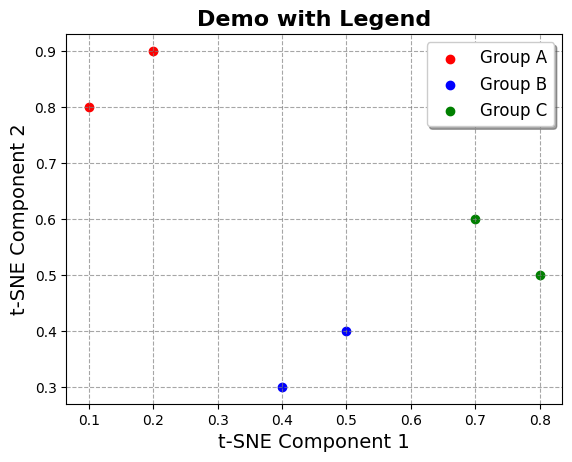

In [ ]:
import matplotlib.pyplot as plt

# Example scatter groups
plt.scatter([0.1, 0.2], [0.8, 0.9], color='red', label='Group A')
plt.scatter([0.4, 0.5], [0.3, 0.4], color='blue', label='Group B')
plt.scatter([0.7, 0.8], [0.6, 0.5], color='green', label='Group C')

# Add legend and plot labels
plt.legend(fontsize=12, loc='best', frameon=True, shadow=True)
plt.title("Demo with Legend", fontsize=16, fontweight='bold')
plt.xlabel("t-SNE Component 1", fontsize=14)
plt.ylabel("t-SNE Component 2", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7, color='gray')
plt.show()


In [ ]:
# Adjust layout to prevent overlap
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [ ]:
# Save and show the plot
plt.savefig("word2vec_embeddings_14M_refined.png", dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>